# 03 — Evaluation, OOD stain ablation & Grad-CAM

Loads a trained checkpoint and produces: accuracy / **macro-F1** / per-class F1, a **confusion
matrix** PNG, the **OOD stain-shift ablation** (the "−15.7% → −1.7%" story), and **Grad-CAM**
overlays per class.

In [1]:
# Locate shared.ipynb regardless of the kernel's working directory, then run it.
from pathlib import Path as _P
_sh = next((p for p in [_P.cwd() / "shared.ipynb",
                        _P("/workspace/shared/ft004/shared.ipynb")] if p.exists()), None)
if _sh is None:
    _hits = list(_P.cwd().rglob("shared.ipynb")) or list(_P("/workspace").rglob("shared.ipynb"))
    _sh = _hits[0] if _hits else None
assert _sh, "shared.ipynb not found - keep it beside the notebooks or in /workspace/shared/ft004"
print("running", _sh)
get_ipython().run_line_magic("run", str(_sh))
import os
from pathlib import Path
PERSIST_DIR = Path(os.environ.get("PERSIST_DIR", "/workspace/shared/ft004"))
OUT = PERSIST_DIR / "outputs"; OUT.mkdir(parents=True, exist_ok=True)
device = get_device(); amp_dtype = get_amp_dtype(device)

RUN_NAME = "phikon_stain"   # which checkpoint dir under PERSIST_DIR/checkpoints
ckpt_path = PERSIST_DIR / "checkpoints" / RUN_NAME / "best.pth"
ck = load_checkpoint(ckpt_path)
cfg, classes = ck["cfg"], ck["classes"]
print("loaded", ckpt_path, "| best macro-F1", round(ck.get("best_metric", 0), 2))


running /workspace/finetuning-004-pathology/shared.ipynb


shared.ipynb loaded: Phase A + B + helpers ready.


loaded /workspace/shared/ft004/checkpoints/phikon_stain/best.pth | best macro-F1 94.98


In [2]:
model = build_model(cfg, num_classes=len(classes)).to(device)
raw_module(model).load_state_dict(ck["model"])
model.eval()
paths = ensure_dataset(PERSIST_DIR)
VAL_DIR = paths["CRC-VAL-HE-7K"]


21:36:59 | INFO | NCT-CRC-HE-100K already present: /workspace/shared/ft004/data/NCT-CRC-HE-100K


21:36:59 | INFO | CRC-VAL-HE-7K already present: /workspace/shared/ft004/data/CRC-VAL-HE-7K/CRC-VAL-HE-7K


21:37:00 | INFO | Dataset CRC-VAL-HE-7K: 7180 imgs / 9 classes


Accuracy 96.66%  |  Macro-F1 94.97%
              precision    recall  f1-score   support

         ADI      1.000     0.988     0.994      1338
        BACK      1.000     1.000     1.000       847
         DEB      0.980     1.000     0.990       339
         LYM      0.998     0.997     0.998       634
         MUC      0.998     0.997     0.998      1035
         MUS      0.905     0.725     0.805       592
        NORM      0.993     1.000     0.997       741
         STR      0.688     0.886     0.775       421
         TUM      0.991     0.994     0.992      1233

    accuracy                          0.967      7180
   macro avg      0.950     0.954     0.950      7180
weighted avg      0.970     0.967     0.967      7180



21:37:25 | INFO | Saved confusion matrix -> /workspace/shared/ft004/outputs/phikon_stain_confusion.png


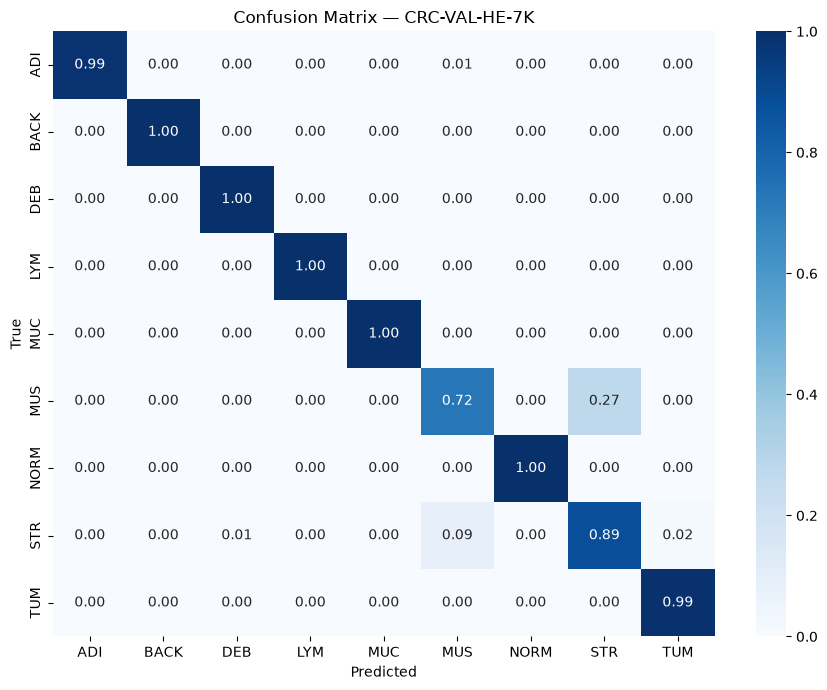

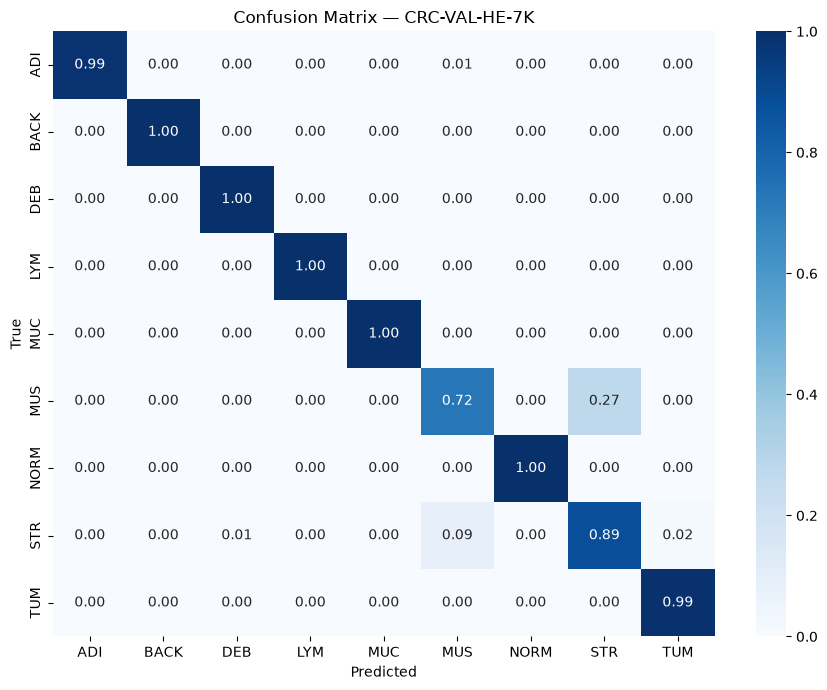

In [3]:
# In-distribution metrics + confusion matrix
val_ds = PathologyPatchDataset(VAL_DIR, classes=classes, transform=build_eval_aug(cfg["img_size"]))
val_loader = DataLoader(val_ds, batch_size=cfg["eval_batch_size"], shuffle=False,
                        num_workers=cfg["num_workers"], pin_memory=True)
preds, labels = run_inference(model, val_loader, device, amp_dtype)
m = compute_metrics(labels, preds, classes)
print(f"Accuracy {m['accuracy']:.2f}%  |  Macro-F1 {m['macro_f1']:.2f}%")
print(classification_report(labels, preds, target_names=classes, digits=3))
plot_confusion_matrix(labels, preds, classes, save_path=str(OUT / f"{RUN_NAME}_confusion.png"))


In [4]:
# OOD stain-shift ablation: same val set, strong synthetic stain shift
ood_ds = PathologyPatchDataset(VAL_DIR, classes=classes, transform=build_ood_aug(cfg["img_size"], theta=0.15))
ood_loader = DataLoader(ood_ds, batch_size=cfg["eval_batch_size"], shuffle=False,
                        num_workers=cfg["num_workers"], pin_memory=True)
op, ol = run_inference(model, ood_loader, device, amp_dtype)
om = compute_metrics(ol, op, classes)
drop = m["accuracy"] - om["accuracy"]
print(f"In-dist acc {m['accuracy']:.2f}%  ->  OOD acc {om['accuracy']:.2f}%  "
      f"(drop {drop:.2f} pts)")
import json
json.dump({"run": RUN_NAME, "in_dist": m, "ood": om, "ood_drop": drop},
          open(OUT / f"{RUN_NAME}_metrics.json", "w"), indent=2)
print("Run this for the stain-aug AND no-stain-aug checkpoints to make the ablation chart.")


21:37:25 | INFO | Dataset CRC-VAL-HE-7K: 7180 imgs / 9 classes


In-dist acc 96.66%  ->  OOD acc 78.02%  (drop 18.64 pts)
Run this for the stain-aug AND no-stain-aug checkpoints to make the ablation chart.


In [5]:
# Grad-CAM: one example per class, saved as overlay PNGs
import numpy as np, matplotlib.pyplot as plt
cam = make_gradcam(raw_module(model), cfg["model"])
if cam is None:
    print(f"Grad-CAM not available for {cfg['model']} (use a timm vit/resnet checkpoint).")
else:
    eval_aug = build_eval_aug(cfg["img_size"])
    fig, axes = plt.subplots(2, len(classes), figsize=(2.0 * len(classes), 4.5))
    for col, c in enumerate(classes):
        i = next(idx for idx, (_, l) in enumerate(val_ds.samples) if classes[l] == c)
        path, _ = val_ds.samples[i]
        from PIL import Image
        raw = np.array(Image.open(path).convert("RGB").resize((cfg["img_size"], cfg["img_size"])))
        x = eval_aug(image=np.array(Image.open(path).convert("RGB")))["image"].unsqueeze(0).to(device)
        heat, pred = cam(x)
        ov = overlay_heatmap(raw, heat)
        axes[0, col].imshow(raw); axes[0, col].axis("off"); axes[0, col].set_title(c, fontsize=9)
        axes[1, col].imshow(ov); axes[1, col].axis("off")
        axes[1, col].set_title(f"->{classes[pred]}", fontsize=8)
    plt.suptitle("Grad-CAM (top: input, bottom: heatmap overlay)", y=1.02)
    plt.tight_layout(); plt.savefig(OUT / f"{RUN_NAME}_gradcam.png", dpi=180, bbox_inches="tight")
    plt.show()
    cam.remove()


21:37:34 | WARNING | Grad-CAM not wired for 'phikon'; returning None


Grad-CAM not available for phikon (use a timm vit/resnet checkpoint).
